In [ ]:
import pandas as pd
from sklearn.preprocessing import StandardScaler, LabelEncoder
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
from xgboost import XGBClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.decomposition import PCA 


In [2]:
df= pd.read_csv('steel_cleaned.csv')

In [3]:
df.shape
print('--------------------------')
df.info()

--------------------------
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 11822 entries, 0 to 11821
Data columns (total 27 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   X_Minimum              11822 non-null  int64  
 1   X_Maximum              11822 non-null  int64  
 2   Y_Minimum              11822 non-null  int64  
 3   Y_Maximum              11822 non-null  int64  
 4   Pixels_Areas           11822 non-null  int64  
 5   X_Perimeter            11822 non-null  int64  
 6   Y_Perimeter            11822 non-null  int64  
 7   Sum_of_Luminosity      11822 non-null  int64  
 8   Minimum_of_Luminosity  11822 non-null  int64  
 9   Maximum_of_Luminosity  11822 non-null  int64  
 10  Length_of_Conveyer     11822 non-null  int64  
 11  Steel_Plate_Thickness  11822 non-null  int64  
 12  Edges_Index            11822 non-null  float64
 13  Empty_Index            11822 non-null  float64
 14  Square_Index           1182

In [4]:
df = df[
    ~df['Defect_Type'].isin([
        'Other_Faults',
        'No_Defect'
    ])
].copy()

print(df['Defect_Type'].value_counts())
# because these two were overlapping and the model was not getting enough evidence to separate them out

Defect_Type
Bumps        4761
K_Scatch     3395
Pastry       1464
Z_Scratch    1150
Stains        567
Dirtiness     485
Name: count, dtype: int64


In [ ]:
steel_encoder = LabelEncoder()
defect_encoder = LabelEncoder()

df['Steel_Type'] = steel_encoder.fit_transform(df['Steel_Type'])
df['Defect_Type'] = defect_encoder.fit_transform(df['Defect_Type'])

print("Steel Mapping:")
print(dict(enumerate(steel_encoder.classes_)))

print("\nDefect Mapping:")
print(dict(enumerate(defect_encoder.classes_)))

Steel Mapping:
{0: 'A300', 1: 'A400'}

Defect Mapping:
{0: 'Bumps', 1: 'Dirtiness', 2: 'K_Scatch', 3: 'Pastry', 4: 'Stains', 5: 'Z_Scratch'}


In [6]:
X = df.drop('Defect_Type', axis=1)
y = df['Defect_Type']

In [ ]:

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.30,   # 70-30 split
    random_state=42,
    stratify=y
)

print("X_train shape:", X_train.shape)
print("X_test shape :", X_test.shape)
print("\nTrain Class Distribution:")
print(y_train.value_counts())

print("\nTest Class Distribution:")
print(y_test.value_counts())

X_train shape: (8275, 26)
X_test shape : (3547, 26)

Train Class Distribution:
Defect_Type
0    3333
2    2376
3    1025
5     805
4     397
1     339
Name: count, dtype: int64

Test Class Distribution:
Defect_Type
0    1428
2    1019
3     439
5     345
4     170
1     146
Name: count, dtype: int64


In [ ]:

rf_model = RandomForestClassifier(
    n_estimators=100,
    random_state=42,
    n_jobs=-1
)

rf_model.fit(X_train, y_train)

rf_pred = rf_model.predict(X_test)

print("RF Accuracy:", accuracy_score(y_test, rf_pred))
print(classification_report(y_test, rf_pred))

RF Accuracy: 0.7978573442345644
              precision    recall  f1-score   support

           0       0.73      0.89      0.80      1428
           1       0.73      0.32      0.45       146
           2       0.97      0.93      0.95      1019
           3       0.60      0.47      0.52       439
           4       0.94      0.85      0.89       170
           5       0.82      0.63      0.71       345

    accuracy                           0.80      3547
   macro avg       0.80      0.68      0.72      3547
weighted avg       0.80      0.80      0.79      3547



In [ ]:

dt_model = DecisionTreeClassifier(
    random_state=42
)

dt_model.fit(X_train, y_train)

dt_pred = dt_model.predict(X_test)

print("DT Accuracy:", accuracy_score(y_test, dt_pred))
print(classification_report(y_test, dt_pred))

DT Accuracy: 0.7127149703975191
              precision    recall  f1-score   support

           0       0.72      0.71      0.72      1428
           1       0.33      0.31      0.32       146
           2       0.92      0.91      0.92      1019
           3       0.40      0.44      0.42       439
           4       0.86      0.81      0.84       170
           5       0.59      0.58      0.58       345

    accuracy                           0.71      3547
   macro avg       0.64      0.63      0.63      3547
weighted avg       0.72      0.71      0.71      3547



In [ ]:

# Train XGBoost
xgb_model = XGBClassifier(
    n_estimators=200,
    max_depth=6,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    eval_metric='mlogloss'
)

xgb_model.fit(X_train, y_train)

# Prediction
xgb_pred = xgb_model.predict(X_test)

# Accuracy
print("Accuracy:", accuracy_score(y_test, xgb_pred))

# Classification Report
print("\nClassification Report:\n")
print(classification_report(y_test, xgb_pred))



Accuracy: 0.8108260501832535

Classification Report:

              precision    recall  f1-score   support

           0       0.76      0.87      0.81      1428
           1       0.65      0.36      0.46       146
           2       0.97      0.94      0.96      1019
           3       0.60      0.48      0.54       439
           4       0.91      0.88      0.89       170
           5       0.80      0.76      0.78       345

    accuracy                           0.81      3547
   macro avg       0.78      0.71      0.74      3547
weighted avg       0.81      0.81      0.80      3547



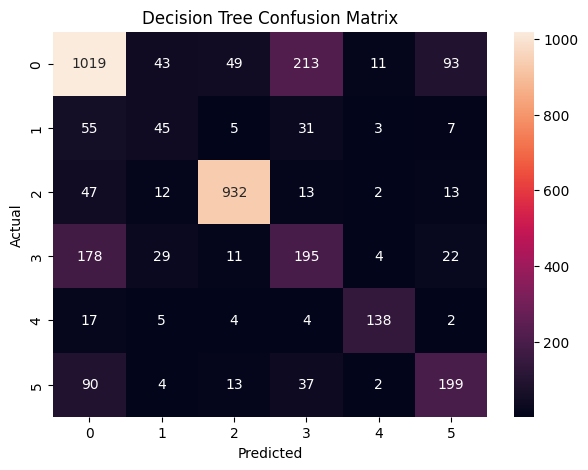

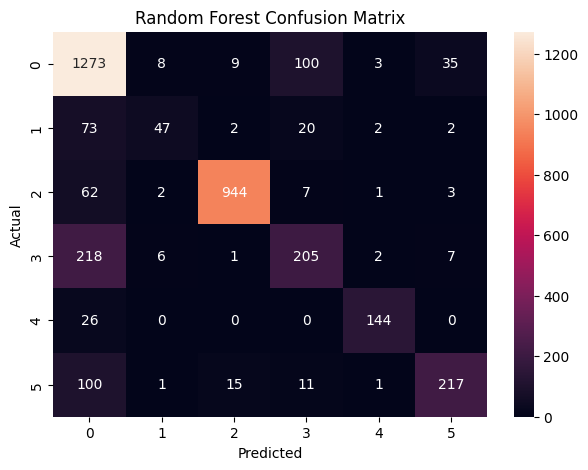

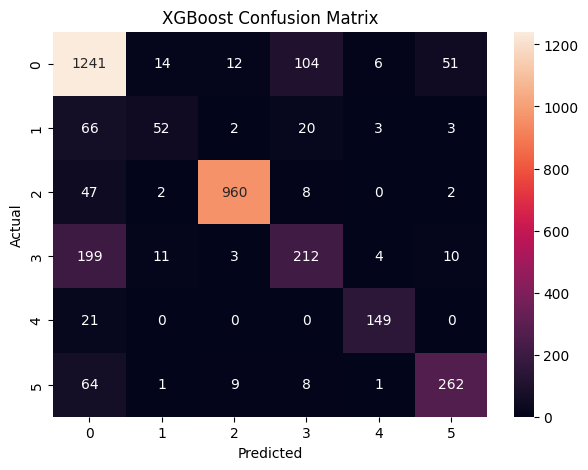

In [ ]:

models = {
    "Decision Tree": dt_pred,
    "Random Forest": rf_pred,
    "XGBoost": xgb_pred
}

for name, pred in models.items():

    plt.figure(figsize=(7,5))

    sns.heatmap(
        confusion_matrix(y_test, pred),
        annot=True,
        fmt='d'
    )

    plt.title(f"{name} Confusion Matrix")
    plt.xlabel("Predicted")
    plt.ylabel("Actual")

    plt.show()

In [ ]:


# Train Accuracy
train_pred = xgb_model.predict(X_train)
train_acc = accuracy_score(y_train, train_pred)

# Test Accuracy
test_pred = xgb_model.predict(X_test)
test_acc = accuracy_score(y_test, test_pred)

# Cross Validation Accuracy
cv_scores = cross_val_score(
    xgb_model,
    X,
    y,
    cv=5,
    scoring='accuracy',
    n_jobs=-1
)

cv_mean = np.mean(cv_scores)
cv_std = np.std(cv_scores)

print(f"Train Accuracy : {train_acc:.4f}")
print(f"Test Accuracy  : {test_acc:.4f}")
print(f"CV Accuracy    : {cv_mean:.4f}")
print(f"CV Std Dev     : {cv_std:.4f}")
print(f"Train-Test Gap : {train_acc-test_acc:.4f}")

Train Accuracy : 0.9513
Test Accuracy  : 0.8108
CV Accuracy    : 0.8052
CV Std Dev     : 0.0038
Train-Test Gap : 0.1405


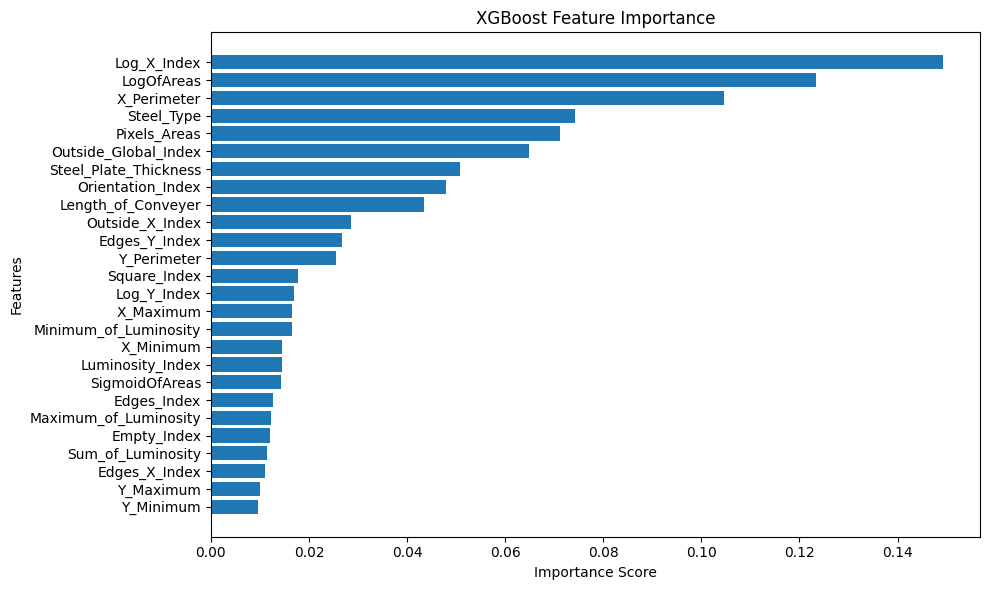

In [ ]:


# Feature Importance DataFrame
importance_df = pd.DataFrame({
    'Feature': X.columns,
    'Importance': xgb_model.feature_importances_
}).sort_values(
    by='Importance',
    ascending=False
)

# Plot
plt.figure(figsize=(10,6))

plt.barh(
    importance_df['Feature'],
    importance_df['Importance']
)

plt.xlabel('Importance Score')
plt.ylabel('Features')
plt.title('XGBoost Feature Importance')

plt.gca().invert_yaxis()

plt.tight_layout()
plt.show()

In [ ]:
# ## Conclusion and Next Steps

# The initial experiments using Random Forest, Decision Tree, and XGBoost models achieved moderate classification performance. However, model 
# evaluation revealed a noticeable gap between training and testing accuracy, indicating the presence of mild overfitting. This suggests that 
# the model may be learning dataset-specific patterns rather than fully generalizing to unseen data.

# Feature importance analysis showed that only a subset of features contributed significantly to the prediction process, while many features had 
# relatively low impact. Therefore, in the next iteration, feature selection will be performed to retain only the most important features. 
# This is expected to reduce model complexity, improve interpretability, and potentially decrease overfitting.

# Furthermore, confusion matrix analysis and PCA visualization revealed significant overlap among certain defect classes, particularly 
# **Dirtiness** and **Pastry**. These classes exhibited high misclassification rates and poor separability in the feature space, making them 
# difficult for the models to distinguish reliably.

# Based on these observations, the next phase of the project will focus on:

# 1. Selecting the top-ranked features identified through feature importance analysis.
# 2. Removing the highly overlapping defect classes (**Dirtiness** and **Pastry**) as a controlled experiment.
# 3. Retraining and evaluating the models on the refined dataset.
# 4. Comparing the new results with the baseline models to assess improvements in accuracy, generalization, and class separability.

# These steps are expected to produce a more robust and deployable defect classification model.
